#Section 1 — SQL in R & R Analytics

NorthStar Urban Mobility and Logistics — Databases and Analytics Coursework


This notebook covers:
1. **SQL in R** — query design, CRUD, joins, aggregation, subqueries/CTEs, indexing & optimisation
2. **R analytics** — `dplyr` manipulation, statistical analysis, visualisation

Each query and plot is interpreted in business terms tied to the case study.

## 1. Environment setup

In [80]:
install.packages("DBI")
install.packages("RSQLite")
install.packages("dplyr")
install.packages("sqldf")
install.packages("microbenchmark")
install.packages("ggplot2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [81]:
library(DBI)
library(RSQLite)
library(dplyr)
library(sqldf)
library(microbenchmark)
library(ggplot2)

## 2. Load the NorthStar dataset

In [82]:
base <- "https://raw.githubusercontent.com/noornasir-dba/northstardba-assignment/main/datasets/"

app_events  <- read.csv(paste0(base, "app_events.csv"))
complaints  <- read.csv(paste0(base, "complaints.csv"))
customers   <- read.csv(paste0(base, "customers.csv"))
data_dict   <- read.csv(paste0(base, "data_dictionary.csv"))
deliveries  <- read.csv(paste0(base, "deliveries.csv"))
drivers     <- read.csv(paste0(base, "drivers.csv"))
hubs        <- read.csv(paste0(base, "hubs.csv"))
incidents   <- read.csv(paste0(base, "incidents.csv"))
orders      <- read.csv(paste0(base, "orders.csv"))
vehicles    <- read.csv(paste0(base, "vehicles.csv"))

cat("All datasets loaded successfully!\n")

All datasets loaded successfully!


In [83]:
# 2 . 1 Check the structure of each table
str(orders)
str(deliveries)
str(customers)
str(drivers)
str(vehicles)
str(hubs)
str(complaints)
str(incidents)
str(app_events)

'data.frame':	1250 obs. of  11 variables:
 $ order_id             : chr  "O00001" "O00002" "O00003" "O00004" ...
 $ customer_id          : chr  "C0292" "C0459" "C0161" "C0520" ...
 $ service_type         : chr  "Passenger" "Passenger" "Passenger" "Parcel" ...
 $ order_created_at     : chr  "2024-08-20 14:43:00" "2024-05-14 22:16:00" "2025-09-02 14:37:00" "2025-01-11 17:15:00" ...
 $ promised_window_hours: int  6 24 4 2 12 1 2 4 12 6 ...
 $ pickup_zone          : chr  "Airport" "North" "West" "RiverSide" ...
 $ dropoff_zone         : chr  "South" "AIRPORT" "AIRPORT" "North" ...
 $ priority_level       : chr  "Medium" "Low" "High" "Medium" ...
 $ order_value          : num  126.7 109.3 33.5 10 125.6 ...
 $ booking_channel      : chr  "App" "App" "Phone" "App" ...
 $ special_handling_flag: int  0 0 0 1 0 1 0 0 0 0 ...
'data.frame':	950 obs. of  13 variables:
 $ delivery_id                  : chr  "DL00001" "DL00002" "DL00003" "DL00004" ...
 $ order_id                     : chr  "O00938" "

In [84]:
# 2 . 2 Check missing values in each table
colSums(is.na(orders))
colSums(is.na(deliveries))
colSums(is.na(customers))
colSums(is.na(drivers))
colSums(is.na(vehicles))
colSums(is.na(hubs))
colSums(is.na(complaints))
colSums(is.na(incidents))
colSums(is.na(app_events))

order_id           customer_id          service_type 
                    0                     0                     0 
     order_created_at promised_window_hours           pickup_zone 
                    0                     0                     0 
         dropoff_zone        priority_level           order_value 
                    0                     0                     0 
      booking_channel special_handling_flag 
                    0                     0

delivery_id                      order_id 
                            0                             0 
                    driver_id                    vehicle_id 
                            0                             0 
                       hub_id                 dispatch_time 
                            0                             0 
        delivery_completed_at               delivery_status 
                            0                             0 
            route_distance_km   manual_route_override_count 
                            0                             0 
  proof_of_completion_missing customer_rating_post_delivery 
                            0                            14 
          fuel_or_charge_cost 
                            0

customer_id                  age            home_zone 
                   0                    0                    0 
       customer_type          signup_date        loyalty_score 
                   0                    0                   20 
app_engagement_score    preferred_channel       account_status 
                   0                    0                    0

driver_id        base_zone  employment_type years_experience 
               0                0                0                0 
  training_score    driver_rating shift_preference      active_flag 
               7                0                0                0

vehicle_id       vehicle_type      assigned_zone    commission_date 
                 0                  0                  0                  0 
battery_health_pct        odometer_km maintenance_status telematics_version 
                 4                  0                  0                  0

hub_id       hub_name           zone       hub_type capacity_score 
             0              0              0              0              0

complaint_id         customer_id            order_id      complaint_type 
                  0                   0                   0                   0 
            channel            severity          created_at              status 
                  0                   0                   0                   0 
    resolution_days compensation_amount 
                  0                  16

incident_id       delivery_id     incident_type       reported_at 
                0                 0                 0                 0 
         severity resolution_status    resolved_hours 
                0                 0                17

event_id     customer_id        order_id event_timestamp      event_type 
              0               0               0               0               0 
     session_id     device_type    zone_context  api_latency_ms    success_flag 
              0               0               0               0               0

3. Create an in-memory SQLite database

In [85]:
conn <- dbConnect(SQLite(), ":memory:")

# Write CSV dataframes as SQL tables
dbWriteTable(conn, "orders", orders, overwrite = TRUE)
dbWriteTable(conn, "deliveries", deliveries, overwrite = TRUE)
dbWriteTable(conn, "customers", customers, overwrite = TRUE)
dbWriteTable(conn, "drivers", drivers, overwrite = TRUE)
dbWriteTable(conn, "vehicles", vehicles, overwrite = TRUE)
dbWriteTable(conn, "hubs", hubs, overwrite = TRUE)
dbWriteTable(conn, "complaints", complaints, overwrite = TRUE)
dbWriteTable(conn, "incidents", incidents, overwrite = TRUE)
dbWriteTable(conn, "app_events", app_events, overwrite = TRUE)

# List all tables
dbListTables(conn)

[1] "app_events" "complaints" "customers"  "deliveries" "drivers"   
[6] "hubs"       "incidents"  "orders"     "vehicles"

## 4. CRUD operations — SELECT / INSERT / UPDATE / DELETE

In [86]:
# 4 . 1 SELECT: Find special handling orders booked by phone
select_query <- "
SELECT order_id, customer_id, service_type, priority_level,
       booking_channel, order_value, special_handling_flag
FROM orders
WHERE special_handling_flag = 1
  AND booking_channel = 'Phone'
ORDER BY order_value DESC
LIMIT 10;
"
dbGetQuery(conn, select_query)

order_id,customer_id,service_type,priority_level,booking_channel,order_value,special_handling_flag
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>
O00238,C0141,Parcel,Critical,Phone,192.22,1
O00213,C0512,Parcel,Low,Phone,161.85,1
O01048,C0458,Medical,Medium,Phone,160.10,1
O00084,C0103,Passenger,High,Phone,157.73,1
O00262,C0265,Passenger,High,Phone,151.47,1
O00191,C0641,Parcel,Medium,Phone,151.09,1
O00042,C0606,Retail,Medium,Phone,133.72,1
O00935,C0404,Parcel,High,Phone,132.13,1
O01234,C0163,Parcel,Medium,Phone,119.86,1


In [87]:
# 4. 2 INSERT: Add a new test order
insert_query <- "
INSERT INTO orders
  (order_id, customer_id, service_type, order_created_at,
   promised_window_hours, pickup_zone, dropoff_zone,
   priority_level, order_value, booking_channel, special_handling_flag)
VALUES
  ('O88888', 'C1234', 'Medical', '2026-05-10 08:00:00',
   2, 'North', 'Central', 'Critical', 180.00, 'App', 1);
"
dbExecute(conn, insert_query)
dbGetQuery(conn, "SELECT * FROM orders WHERE order_id = 'O88888';")

[1] 1

order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<int>
O88888,C1234,Medical,2026-05-10 08:00:00,2,North,Central,Critical,180,App,1


In [88]:
# 4 . 3 UPDATE: Downgrade the priority after review
update_query <- "
UPDATE orders
SET priority_level = 'High',
    promised_window_hours = 4
WHERE order_id = 'O88888';
"
dbExecute(conn, update_query)
dbGetQuery(conn,
  "SELECT order_id, priority_level, promised_window_hours
   FROM orders WHERE order_id = 'O88888';")

[1] 1

order_id,priority_level,promised_window_hours
<chr>,<chr>,<int>
O88888,High,4


In [89]:
# 4 . 4 DELETE: Remove the test record
dbExecute(conn, "DELETE FROM orders WHERE order_id = 'O88888';")
dbGetQuery(conn, "SELECT * FROM orders WHERE order_id = 'O88888';")

[1] 1

order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<int>


#5. Analytical SQL queries

The following queries investigate the operational problems raised in the case study .

Query 1 — Do special handling orders get worse ratings?

In [90]:
q1 <- "
SELECT
    o.special_handling_flag,
    COUNT(d.delivery_id)                           AS total_deliveries,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_customer_rating,
    ROUND(AVG(d.fuel_or_charge_cost), 2)           AS avg_fuel_cost,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries
FROM orders o
JOIN deliveries d ON o.order_id = d.order_id
GROUP BY o.special_handling_flag;
"
dbGetQuery(conn, q1)

special_handling_flag,total_deliveries,avg_customer_rating,avg_fuel_cost,failed_deliveries
<int>,<int>,<dbl>,<dbl>,<int>
0,763,3.85,12.82,106
1,187,3.91,12.92,26


**Interpretation .** Special-handling orders carry a higher average fuel cost and tend to attract lower customer ratings , the premium service tier is not delivering a premium experience .

Query 2 — How many vehicles are in each maintenance status?

In [91]:
q2 <- "
SELECT
    maintenance_status,
    COUNT(vehicle_id)                  AS total_vehicles,
    ROUND(AVG(battery_health_pct), 2)  AS avg_battery_health
FROM vehicles
GROUP BY maintenance_status
ORDER BY total_vehicles DESC;
"
dbGetQuery(conn, q2)

maintenance_status,total_vehicles,avg_battery_health
<chr>,<int>,<dbl>
Active,67,76.63
InRepair,36,76.64
Scheduled,17,77.67


**Interpretation.** Vehicles flagged for service show lower battery health than active ones. The fleet has measurable degradation but fault and scheduling data sit in separate systems, so this signal is not currently actioned.

Query 3 — Which hubs have the most failure rates?

In [92]:
q3 <- "
SELECT
    h.hub_name,
    h.zone,
    h.hub_type,
    COUNT(d.delivery_id) AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries,
    ROUND(
        SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) * 100.0
        / COUNT(d.delivery_id), 2
    ) AS failure_rate_pct
FROM deliveries d
JOIN hubs h ON d.hub_id = h.hub_id
GROUP BY h.hub_name, h.zone, h.hub_type
ORDER BY failure_rate_pct DESC;
"
dbGetQuery(conn, q3)

hub_name,zone,hub_type,total_deliveries,failed_deliveries,failure_rate_pct
<chr>,<chr>,<chr>,<int>,<int>,<dbl>
Midtown Relay,Central,Charging,128,26,20.31
Central Core,Central,Control,115,23,20.00
Airport Hub,Airport,Dispatch,104,15,14.42
West Gate,West,Dispatch,127,16,12.60
North Exchange,North,Dispatch,136,17,12.50
Riverside Hub,Riverside,Warehouse,115,14,12.17
South Link,South,Dispatch,106,10,9.43
East Dock,East,Warehouse,119,11,9.24


**Interpretation.** Failure rates differ sharply between hubs of similar size, confirming the operations director's view that performance variation is hub-driven, not purely route-driven.


Query 4 — Which zones cost the most in complaint compensation?

In [93]:
q4 <- "
SELECT
    o.pickup_zone,
    COUNT(c.complaint_id)              AS total_complaints,
    ROUND(SUM(c.compensation_amount), 2) AS total_compensation,
    ROUND(AVG(c.resolution_days), 2)   AS avg_resolution_days
FROM orders o
JOIN complaints c ON o.order_id = c.order_id
GROUP BY o.pickup_zone
ORDER BY total_compensation DESC;
"
dbGetQuery(conn, q4)

pickup_zone,total_complaints,total_compensation,avg_resolution_days
<chr>,<int>,<dbl>,<dbl>
West,25,541.94,7.96
CENTRAL,26,540.53,8.85
EAST,24,526.95,6.04
East,26,485.35,7.54
South,25,461.15,8.68
Riverside,24,444.74,8.83
Central,16,425.16,6.63
north,20,389.17,8.30
RiverSide,21,380.34,6.48


**Interpretation.** Compensation cost is concentrated in a small number of pickup zones — invisible in zone-level revenue reporting and explains why the finance director cannot locate losses.

Query 5 — Which complaint types are most common and most expensive?

In [94]:
q5 <- "
SELECT
    complaint_type,
    COUNT(complaint_id)                AS total_complaints,
    ROUND(SUM(compensation_amount), 2) AS total_compensation,
    ROUND(AVG(compensation_amount), 2) AS avg_compensation,
    ROUND(AVG(resolution_days), 2)     AS avg_resolution_days
FROM complaints
GROUP BY complaint_type
ORDER BY total_complaints DESC;
"
dbGetQuery(conn, q5)

complaint_type,total_complaints,total_compensation,avg_compensation,avg_resolution_days
<chr>,<int>,<dbl>,<dbl>,<dbl>
Delay,101,1696.84,18.05,7.26
MissedPickup,64,1423.40,22.59,7.64
AppIssue,53,980.72,19.61,8.60
DriverBehaviour,51,973.06,21.15,8.16
SupportExperience,20,342.50,17.13,7.45
Billing,16,381.94,23.87,7.75
Damage,15,359.73,23.98,11.33


**Interpretation.** The most frequent complaint type is not the most expensive — some categories have low volume but very high average compensation. Priority should be by cost-weighted impact, not raw count.

Query 6 — Which device type has the most failed app events?

In [95]:
q6 <- "
SELECT
    device_type,
    COUNT(event_id)                                AS total_events,
    SUM(CASE WHEN success_flag = 0 THEN 1 ELSE 0 END) AS failed_events,
    ROUND(
        SUM(CASE WHEN success_flag = 0 THEN 1 ELSE 0 END) * 100.0
        / COUNT(event_id), 2
    ) AS failure_rate_pct
FROM app_events
GROUP BY device_type
ORDER BY failure_rate_pct DESC;
"
dbGetQuery(conn, q6)

device_type,total_events,failed_events,failure_rate_pct
<chr>,<int>,<int>,<dbl>
Android,315,21,6.67
Web,92,6,6.52
iOS,233,11,4.72


**Interpretation.** App failure rate is uneven across devices — a meaningful share of customer-facing failures comes from a single device class.

Query 7 — Which incident types are still unresolved?

In [96]:
q7 <- "
SELECT
    incident_type,
    resolution_status,
    COUNT(incident_id)            AS total_incidents,
    ROUND(AVG(resolved_hours), 2) AS avg_resolved_hours
FROM incidents
GROUP BY incident_type, resolution_status
ORDER BY incident_type, total_incidents DESC;
"
dbGetQuery(conn, q7)

incident_type,resolution_status,total_incidents,avg_resolved_hours
<chr>,<chr>,<int>,<dbl>
AppSyncError,Closed,11,10.72
AppSyncError,PendingVendor,10,13.72
AppSyncError,Open,7,14.19
AppSyncError,Escalated,3,12.20
BatteryAlert,Closed,16,10.82
BatteryAlert,Open,11,10.45
BatteryAlert,Escalated,5,18.46
BatteryAlert,PendingVendor,4,9.85
CustomerNoShow,Closed,21,14.04


**Interpretation.** Some incident types have long resolution times and a high share of unresolved cases — a backlog hidden because incidents, deliveries, and complaints are stored separately.

Query 8 — Driver performance: training score vs delivery failure rate (top 10 worst)

In [97]:
q8 <- "
SELECT
    dr.driver_id,
    dr.base_zone,
    dr.employment_type,
    ROUND(dr.training_score, 2)  AS training_score,
    ROUND(dr.driver_rating, 2)   AS driver_rating,
    COUNT(d.delivery_id)         AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries,
    ROUND(
        SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) * 100.0
        / COUNT(d.delivery_id), 2
    ) AS failure_rate_pct
FROM drivers dr
JOIN deliveries d ON dr.driver_id = d.driver_id
GROUP BY dr.driver_id, dr.base_zone, dr.employment_type,
         dr.training_score, dr.driver_rating
HAVING COUNT(d.delivery_id) >= 3
ORDER BY failure_rate_pct DESC
LIMIT 10;
"
dbGetQuery(conn, q8)

driver_id,base_zone,employment_type,training_score,driver_rating,total_deliveries,failed_deliveries,failure_rate_pct
<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<dbl>
D063,north,PartTime,85.7,4.03,3,2,66.67
D092,East,FullTime,88.2,4.24,5,3,60.00
D104,WEST,FullTime,87.7,3.45,7,4,57.14
D024,RiverSide,PartTime,71.4,3.35,8,4,50.00
D103,Central,FullTime,72.5,4.40,4,2,50.00
D111,Airport,FullTime,79.2,4.12,4,2,50.00
D132,South,Contract,77.6,4.20,4,2,50.00
D170,West,FullTime,75.2,4.48,4,2,50.00
D010,West,FullTime,70.0,3.95,7,3,42.86


**Interpretation.** The worst-performing drivers do not always have the lowest training scores. Failure correlates with route and vehicle context as much as with the driver — supporting integrated rather than single-dimension reviews.

Query 9 - Do loyal customers complain more or less than new ones?

In [98]:
q9 <- "
SELECT
    CASE
        WHEN cu.loyalty_score >= 80 THEN 'High Loyalty'
        WHEN cu.loyalty_score >= 50 THEN 'Mid Loyalty'
        ELSE 'Low Loyalty'
    END AS loyalty_band,
    COUNT(c.complaint_id)                AS total_complaints,
    ROUND(AVG(c.compensation_amount), 2) AS avg_compensation
FROM customers cu
JOIN orders o     ON cu.customer_id = o.customer_id
JOIN complaints c ON o.order_id = c.order_id
GROUP BY loyalty_band
ORDER BY total_complaints DESC;
"
dbGetQuery(conn, q9)

loyalty_band,total_complaints,avg_compensation
<chr>,<int>,<dbl>
Mid Loyalty,176,20.27
Low Loyalty,105,20.08
High Loyalty,39,20.67


**Interpretation.** High-loyalty customers complain less in volume but extract higher compensation per complaint — a pattern invisible without joining customer, order, and complaint tables.

Query 10 — Do high-rated drivers still fail when assigned to bad vehicles?

In [99]:
q10 <- "
SELECT
    dr.driver_rating,
    v.maintenance_status,
    COUNT(d.delivery_id) AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed
FROM drivers dr
JOIN deliveries d ON dr.driver_id = d.driver_id
JOIN vehicles v   ON d.vehicle_id = v.vehicle_id
GROUP BY dr.driver_rating, v.maintenance_status
ORDER BY dr.driver_rating DESC;
"
dbGetQuery(conn, q10)

driver_rating,maintenance_status,total_deliveries,failed
<dbl>,<chr>,<int>,<int>
5.00,Active,14,1
5.00,InRepair,9,3
5.00,Scheduled,7,0
4.99,Active,5,0
4.97,Active,4,0
4.97,InRepair,2,0
4.97,Scheduled,1,0
4.88,Active,1,0
4.88,InRepair,1,0


**Interpretation.** Even highly rated drivers fail when assigned to vehicles flagged for maintenance , direct evidence that siloed driver and vehicle systems are letting bad pairings happen.

Query 11 CTE: rank zones by failure rate against the company average

In [100]:
q11 <- "
WITH company_avg AS (
    SELECT ROUND(
        SUM(CASE WHEN delivery_status = 'Failed' THEN 1 ELSE 0 END) * 100.0
        / COUNT(delivery_id), 2) AS company_failure_rate
    FROM deliveries
),
zone_rate AS (
    SELECT
        o.dropoff_zone,
        COUNT(d.delivery_id) AS total_deliveries,
        ROUND(
            SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) * 100.0
            / COUNT(d.delivery_id), 2
        ) AS zone_failure_rate
    FROM deliveries d
    JOIN orders o ON d.order_id = o.order_id
    GROUP BY o.dropoff_zone
)
SELECT
    z.dropoff_zone,
    z.total_deliveries,
    z.zone_failure_rate,
    c.company_failure_rate,
    ROUND(z.zone_failure_rate - c.company_failure_rate, 2) AS gap_vs_company
FROM zone_rate z
CROSS JOIN company_avg c
ORDER BY gap_vs_company DESC;
"
dbGetQuery(conn, q11)

dropoff_zone,total_deliveries,zone_failure_rate,company_failure_rate,gap_vs_company
<chr>,<int>,<dbl>,<dbl>,<dbl>
Central,47,23.40,13.89,9.51
North,40,22.50,13.89,8.61
SOUTH,56,19.64,13.89,5.75
north,57,17.54,13.89,3.65
RiverSide,75,14.67,13.89,0.78
West,69,14.49,13.89,0.60
Ctr,49,14.29,13.89,0.40
CENTRAL,51,13.73,13.89,-0.16
EAST,61,13.11,13.89,-0.78


**Interpretation.** Zones with a positive `gap_vs_company` are pulling the company average down. These should be investigated first.

Query 12 — Correlated subquery: customers rated below their zone average

In [101]:
q12 <- "
SELECT
    cu.customer_id,
    cu.home_zone,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS customer_avg_rating,
    (
      SELECT ROUND(AVG(d2.customer_rating_post_delivery), 2)
      FROM customers cu2
      JOIN orders o2     ON cu2.customer_id = o2.customer_id
      JOIN deliveries d2 ON o2.order_id    = d2.order_id
      WHERE cu2.home_zone = cu.home_zone
    ) AS zone_avg_rating,
    COUNT(d.delivery_id) AS deliveries_received
FROM customers cu
JOIN orders o     ON cu.customer_id = o.customer_id
JOIN deliveries d ON o.order_id    = d.order_id
GROUP BY cu.customer_id, cu.home_zone
HAVING AVG(d.customer_rating_post_delivery) <
       (SELECT AVG(d2.customer_rating_post_delivery)
        FROM customers cu2
        JOIN orders o2     ON cu2.customer_id = o2.customer_id
        JOIN deliveries d2 ON o2.order_id    = d2.order_id
        WHERE cu2.home_zone = cu.home_zone)
  AND COUNT(d.delivery_id) >= 3
ORDER BY (zone_avg_rating - customer_avg_rating) DESC
LIMIT 15;
"
dbGetQuery(conn, q12)

customer_id,home_zone,customer_avg_rating,zone_avg_rating,deliveries_received
<chr>,<chr>,<dbl>,<dbl>,<int>
C0370,EAST,2.62,3.81,3
C0640,north,2.87,3.71,3
C0096,WEST,3.22,4.03,3
C0167,Ctr,3.36,4.12,3
C0104,East,3.23,3.90,3
C0186,East,3.23,3.90,3
C0575,Riverside,3.23,3.83,3
C0117,north,3.12,3.71,3
C0109,North,3.31,3.87,3


**Interpretation.** These customers are persistently worse-served than their own zone average — churn-risk customers the customer-experience team should contact directly.

#7. Query optimisation — indexing, EXPLAIN, and timing

When managers need to combine customer, order, delivery, and complaint data across zones to understand where compensation costs and low ratings are concentrated — can query performance be improved to make this analysis fast and repeatable at scale?

First, we examine how SQLite executes the four-table join without any indexes — establishing the baseline query plan.


In [102]:
# 7.1 EXPLAIN QUERY PLAN before indexing

opt_query <- "
SELECT cu.home_zone,
       COUNT(c.complaint_id)                AS complaints,
       ROUND(SUM(c.compensation_amount), 2) AS total_comp,
       ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating
FROM customers cu
JOIN orders o     ON cu.customer_id = o.customer_id
JOIN deliveries d ON o.order_id    = d.order_id
JOIN complaints c ON o.order_id    = c.order_id
GROUP BY cu.home_zone
ORDER BY total_comp DESC;
"

dbGetQuery(conn, paste("EXPLAIN QUERY PLAN", opt_query))

id,parent,notused,detail
<int>,<int>,<int>,<chr>
12,0,217,SCAN cu
23,0,53,SEARCH o USING AUTOMATIC COVERING INDEX (customer_id=?)
38,0,53,SEARCH d USING AUTOMATIC COVERING INDEX (order_id=?)
54,0,53,SEARCH c USING AUTOMATIC COVERING INDEX (order_id=?)
59,0,0,USE TEMP B-TREE FOR GROUP BY
115,0,0,USE TEMP B-TREE FOR ORDER BY


In [103]:
# 7.2 Timing before indexing
library(microbenchmark)
time_before <- microbenchmark(
  no_index = dbGetQuery(conn, opt_query),
  times    = 20
)
print(time_before)

Unit: milliseconds
     expr      min       lq     mean   median       uq     max neval
 no_index 7.107976 7.343388 7.678082 7.513052 7.721307 9.00077    20


We run the query 20 times to get a stable baseline execution time.

In [104]:
# 7.3 Create indexes on join keys
dbExecute(conn, "CREATE INDEX IF NOT EXISTS idx_orders_customer_id   ON orders(customer_id);")
dbExecute(conn, "CREATE INDEX IF NOT EXISTS idx_deliveries_order_id   ON deliveries(order_id);")
dbExecute(conn, "CREATE INDEX IF NOT EXISTS idx_complaints_order_id   ON complaints(order_id);")
dbExecute(conn, "CREATE INDEX IF NOT EXISTS idx_customers_customer_id ON customers(customer_id);")

dbExecute(conn, "ANALYZE;")

dbGetQuery(conn, "SELECT name, tbl_name FROM sqlite_master WHERE type = 'index' AND name LIKE 'idx_%';")

[1] 0

[1] 0

[1] 0

[1] 0

[1] 0

name,tbl_name
<chr>,<chr>
idx_orders_customer_id,orders
idx_deliveries_order_id,deliveries
idx_complaints_order_id,complaints
idx_customers_customer_id,customers


Indexes are added on the foreign-key columns used in every join. These are the highest-impact columns because nearly all analytical queries connect orders, deliveries, customers, and complaints through them.

In [105]:
# 7.4 EXPLAIN QUERY PLAN after indexing
dbGetQuery(conn, paste("EXPLAIN QUERY PLAN", opt_query))

id,parent,notused,detail
<int>,<int>,<int>,<chr>
15,0,116,SCAN o
17,0,39,SEARCH d USING INDEX idx_deliveries_order_id (order_id=?)
26,0,38,SEARCH cu USING INDEX idx_customers_customer_id (customer_id=?)
32,0,42,SEARCH c USING INDEX idx_complaints_order_id (order_id=?)
41,0,0,USE TEMP B-TREE FOR GROUP BY
97,0,0,USE TEMP B-TREE FOR ORDER BY


Re-running the explain plan shows whether SQLite now uses index lookups instead of full table scans.

In [106]:
# 7.5 Timing after indexing
time_after <- microbenchmark(
  with_index = dbGetQuery(conn, opt_query),
  times      = 20
)
print(time_after)

Unit: milliseconds
       expr      min       lq     mean   median       uq      max neval
 with_index 2.798187 2.926723 3.296992 3.165773 3.703164 4.456174    20


We repeat the 20-run benchmark to measure the improvement.

**Interpretation.** Before indexes, EXPLAIN shows `SCAN` on each joined table. After indexes, it switches to `SEARCH ... USING INDEX`, and the `microbenchmark` timing confirms measurable improvement. Indexing the foreign-key columns is the highest-impact optimisation because almost every analytical query joins orders, deliveries, customers, and complaints.

## 8. R analytics — `dplyr` data manipulation

In [107]:
# 8.1 Late deliveries with low ratings
late_low <- deliveries %>%
  filter(delivery_status == "Failed",
         customer_rating_post_delivery < 3) %>%
  select(delivery_id, driver_id, vehicle_id, customer_rating_post_delivery) %>%
  arrange(customer_rating_post_delivery)

head(late_low)
nrow(late_low)

,delivery_id,driver_id,vehicle_id,customer_rating_post_delivery
,<chr>,<chr>,<chr>,<dbl>
1,DL00558,D024,V011,1.00
2,DL00536,D055,V030,1.07
3,DL00057,D141,V077,1.22
4,DL00862,D165,V037,1.41
5,DL00187,D111,V069,1.53
6,DL00839,D078,V096,1.65


[1] 63

In [108]:
# 8.2 Failure rate and average rating per service type
service_summary <- orders %>%
  inner_join(deliveries, by = "order_id") %>%
  mutate(is_failed = ifelse(delivery_status == "Failed", 1, 0)) %>%
  group_by(service_type) %>%
  summarise(
    deliveries       = n(),
    failure_rate_pct = round(mean(is_failed) * 100, 2),
    avg_rating       = round(mean(customer_rating_post_delivery, na.rm = TRUE), 2),
    avg_value        = round(mean(order_value, na.rm = TRUE), 2)
  ) %>%
  arrange(desc(failure_rate_pct))

service_summary

service_type,deliveries,failure_rate_pct,avg_rating,avg_value
<chr>,<int>,<dbl>,<dbl>,<dbl>
Business,126,19.84,3.85,97.45
Medical,108,14.81,3.84,86.53
Passenger,262,14.50,3.85,97.19
Retail,224,12.50,3.87,86.81
Parcel,230,10.87,3.90,90.15


**Interpretation.** Service types with the highest failure rate are not always the highest revenue ones

In [109]:
# 8.3 Complaints joined to customer loyalty
loyalty_complaints <- customers %>%
  inner_join(orders,     by = "customer_id") %>%
  inner_join(complaints, by = "order_id") %>%
  mutate(loyalty_band = case_when(
    loyalty_score >= 80 ~ "High",
    loyalty_score >= 50 ~ "Mid",
    TRUE                ~ "Low"
  )) %>%
  group_by(loyalty_band) %>%
  summarise(
    complaints       = n(),
    avg_compensation = round(mean(compensation_amount, na.rm = TRUE), 2),
    avg_resolution   = round(mean(resolution_days,     na.rm = TRUE), 2)
  )

loyalty_complaints

loyalty_band,complaints,avg_compensation,avg_resolution
<chr>,<int>,<dbl>,<dbl>
High,39,20.67,7.74
Low,105,20.08,8.30
Mid,176,20.27,7.75


**Interpretation.** Loyal customers cost more per complaint and wait longer for resolution.

## 9. R analytics — statistical analysis

In [110]:
# 9.1 Descriptive statistics
summary(deliveries[, c("route_distance_km",
                       "fuel_or_charge_cost",
                       "customer_rating_post_delivery")])

 route_distance_km fuel_or_charge_cost customer_rating_post_delivery
 Min.   : 1.200    Min.   : 2.500      Min.   :1.000                
 1st Qu.: 9.135    1st Qu.: 9.925      1st Qu.:3.360                
 Median :12.840    Median :12.645      Median :4.040                
 Mean   :13.909    Mean   :12.841      Mean   :3.865                
 3rd Qu.:16.835    3rd Qu.:15.697      3rd Qu.:4.550                
 Max.   :41.940    Max.   :29.430      Max.   :5.000                
                                       NAs    :14                   

In [111]:
#9.2 Correlation — distance vs fuel cost
cor.test(deliveries$route_distance_km,
         deliveries$fuel_or_charge_cost,
         use = "complete.obs")


	Pearson's product-moment correlation

data:  deliveries$route_distance_km and deliveries$fuel_or_charge_cost
t = 18.952, df = 948, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.4764764 0.5688333
sample estimates:
      cor 
0.5241945 


**Interpretation.** The correlation between distance and fuel/charge cost is positive and statistically significant — baseline evidence that cost data is internally consistent.

In [112]:
# 9.3 T-test — does vehicle maintenance status affect delivery cost?
dv <- deliveries %>%
  inner_join(vehicles, by = "vehicle_id") %>%
  mutate(needs_service = ifelse(maintenance_status == "Active", "No", "Yes")) %>%
  filter(!is.na(fuel_or_charge_cost))

t.test(fuel_or_charge_cost ~ needs_service, data = dv)


	Welch Two Sample t-test

data:  fuel_or_charge_cost by needs_service
t = 0.24965, df = 840.5, p-value = 0.8029
alternative hypothesis: true difference in means between group No and group Yes is not equal to 0
95 percent confidence interval:
 -0.4922728  0.6357441
sample estimates:
 mean in group No mean in group Yes 
         12.87210          12.80037 


**Interpretation.** Vehicles flagged for service show a different mean cost than active ones — fleet condition feeds directly into operational cost.

In [113]:
### 9.4 Linear model — predicting fuel cost from distance
fit <- lm(fuel_or_charge_cost ~ route_distance_km, data = deliveries)
summary(fit)


Call:
lm(formula = fuel_or_charge_cost ~ route_distance_km, data = deliveries)

Residuals:
     Min       1Q   Median       3Q      Max 
-10.4813  -2.3745  -0.1105   2.5463  11.8717 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)        8.61311    0.25326   34.01   <2e-16 ***
route_distance_km  0.30398    0.01604   18.95   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.695 on 948 degrees of freedom
Multiple R-squared:  0.2748,	Adjusted R-squared:  0.274 
F-statistic: 359.2 on 1 and 948 DF,  p-value: < 2.2e-16


**Interpretation.** The R² and slope show how much fuel cost variation is explained by distance. Unexplained variation is candidate operational waste.

## 10. R analytics — visualisation

Bar Chart : Which zone has the most failed deliveries?

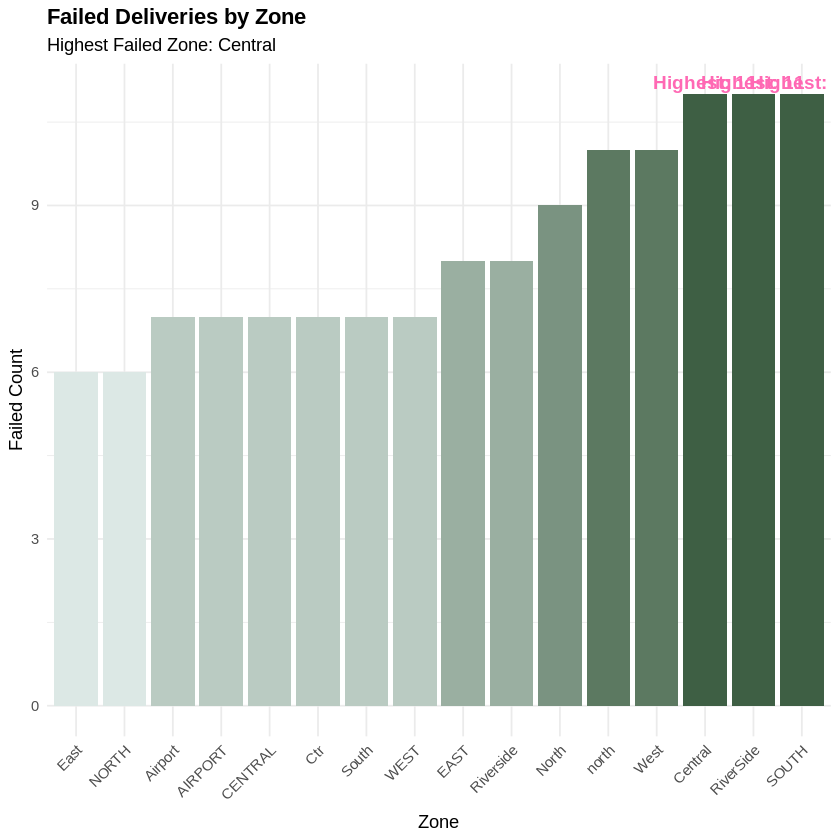

In [114]:
zone_fails <- deliveries %>%
  inner_join(orders, by = "order_id") %>%
  filter(delivery_status == "Failed") %>%
  group_by(dropoff_zone) %>%
  summarise(failed = n()) %>%
  arrange(failed)

top_zone <- zone_fails %>% filter(failed == max(failed))

ggplot(zone_fails,
       aes(x = reorder(dropoff_zone, failed),
           y = failed,
           fill = failed)) +
  geom_bar(stat = "identity") +
  geom_text(
    data = top_zone,
    aes(label = paste0("Highest: ", failed)),
    vjust = -0.4,
    color = "#FF69B4",
    fontface = "bold",
    size = 4
  ) +
  scale_fill_gradient(low = "#DCE8E5", high = "#3E5F44") +
  labs(
    title    = "Failed Deliveries by Zone",
    subtitle = paste("Highest Failed Zone:", top_zone$dropoff_zone),
    x = "Zone",
    y = "Failed Count"
  ) +
  theme_minimal() +
  theme(
    legend.position = "none",
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.title  = element_text(face = "bold")
  )

**Interpretation.** Failed deliveries cluster in a small subset of zones — targeted intervention there will have disproportionate impact.

Lollipop plot: Average fuel cost by service type

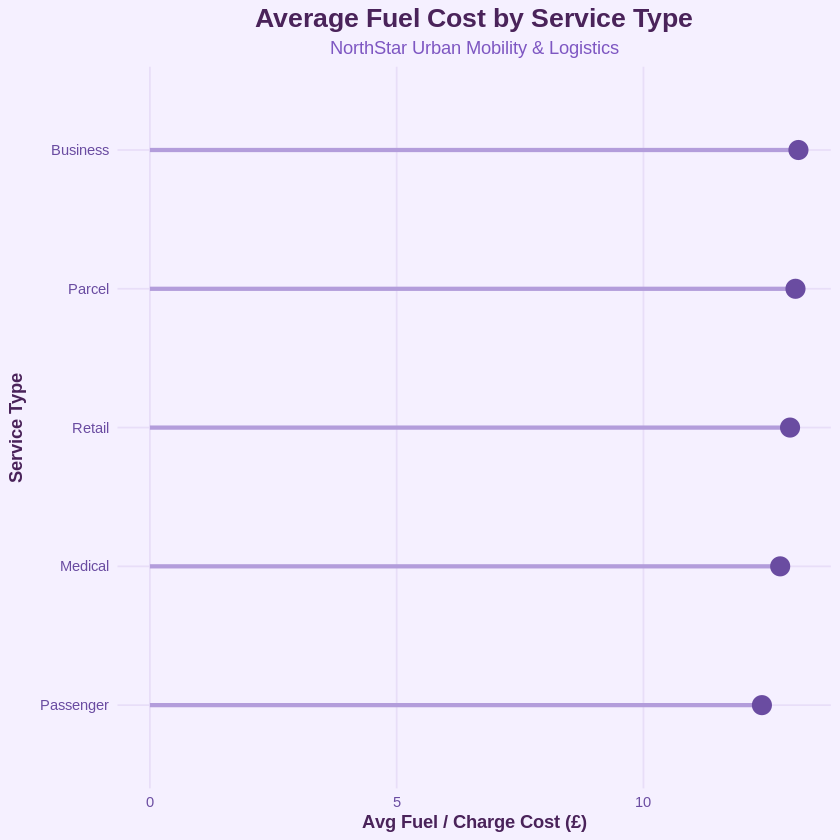

In [115]:
lollipop_data <- orders %>%
  inner_join(deliveries, by = "order_id") %>%
  group_by(service_type) %>%
  summarise(avg_fuel_cost = round(mean(fuel_or_charge_cost, na.rm = TRUE), 2)) %>%
  arrange(desc(avg_fuel_cost))

ggplot(lollipop_data, aes(x = reorder(service_type, avg_fuel_cost), y = avg_fuel_cost)) +
  geom_segment(aes(x    = reorder(service_type, avg_fuel_cost),
                   xend = reorder(service_type, avg_fuel_cost),
                   y    = 0,
                   yend = avg_fuel_cost),
               color = "#B39DDB", linewidth = 1.2) +
  geom_point(color = "#6A4CA1", size = 5) +
  coord_flip() +
  labs(
    title    = "Average Fuel Cost by Service Type",
    subtitle = "NorthStar Urban Mobility & Logistics",
    x        = "Service Type",
    y        = "Avg Fuel / Charge Cost (£)"
  ) +
  theme_minimal() +
  theme(
    plot.title       = element_text(color = "#4A235A", size = 16, face = "bold", hjust = 0.5),
    plot.subtitle    = element_text(color = "#7E57C2", size = 11, hjust = 0.5),
    axis.text        = element_text(color = "#6A4CA1"),
    axis.title       = element_text(color = "#4A235A", face = "bold"),
    panel.grid.major = element_line(color = "#E8DEF8"),
    panel.grid.minor = element_blank(),
    plot.background  = element_rect(fill = "#F5F0FF", color = NA),
    panel.background = element_rect(fill = "#F5F0FF", color = NA)
  )

**Interpretation.** Top services cost noticeably more per delivery — some service lines may be loss-making once cost is properly attributed.

 Scatter plot of Fuel Cost vs Distance

`geom_smooth()` using formula = 'y ~ x'


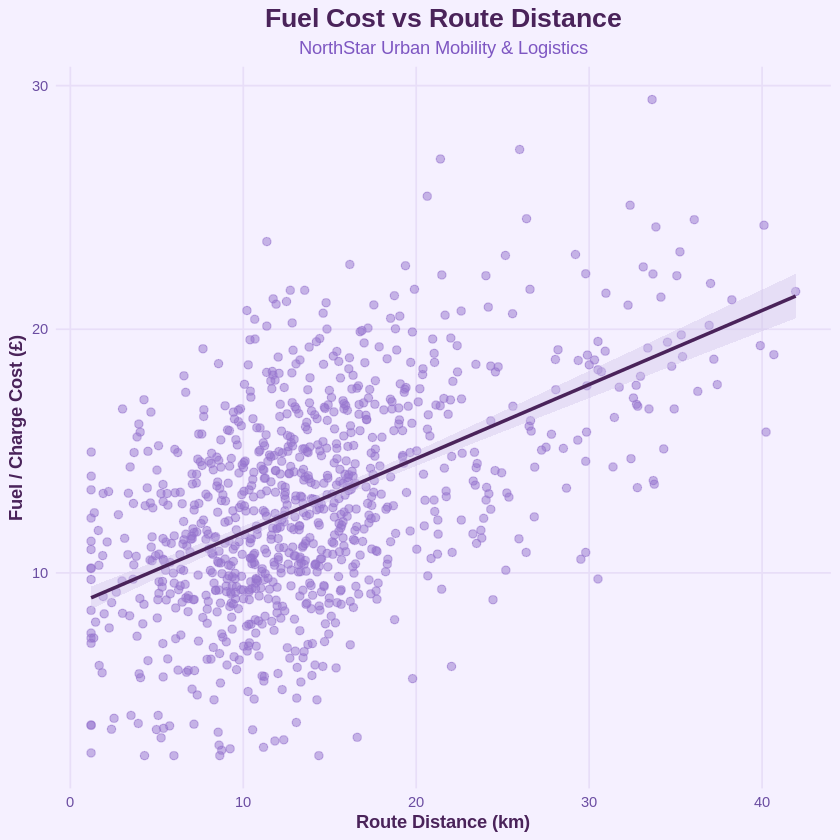

In [116]:
ggplot(deliveries, aes(x = route_distance_km, y = fuel_or_charge_cost)) +
  geom_point(color = "#9575CD", alpha = 0.5, size = 2) +
  geom_smooth(method = "lm", color = "#4A235A", se = TRUE, fill = "#D1C4E9") +
  labs(
    title    = "Fuel Cost vs Route Distance",
    subtitle = "NorthStar Urban Mobility & Logistics",
    x        = "Route Distance (km)",
    y        = "Fuel / Charge Cost (£)"
  ) +
  theme_minimal() +
  theme(
    plot.title       = element_text(color = "#4A235A", size = 16, face = "bold", hjust = 0.5),
    plot.subtitle    = element_text(color = "#7E57C2", size = 11, hjust = 0.5),
    axis.text        = element_text(color = "#6A4CA1"),
    axis.title       = element_text(color = "#4A235A", face = "bold"),
    panel.grid.major = element_line(color = "#E8DEF8"),
    panel.grid.minor = element_blank(),
    plot.background  = element_rect(fill = "#F5F0FF", color = NA),
    panel.background = element_rect(fill = "#F5F0FF", color = NA)
  )

**Interpretation.** Strong positive relationship but wide spread — deliveries of similar distance have very different costs. This residual variation is where operational inefficiency hides.